# Project 2: Credit Risk and Statistical Learning

**Names of all group members:**
- Mahe Velay (mahe.velay@epfl.ch)
- Adelaïde Robert (adelaide.robert@epfl.ch)
- Timothée Pottié (timothee.pottie@epfl.ch)


---

In [43]:
# Exercise 1.
import numpy as np
np.random.seed(0)  # for reproducibility

# simulate explanatory variables x

n = 10000
m = 20000
N = n + m

# x1 = np.random.randint(18, 81, size=N)
x1 = np.round(np.random.uniform(18, 80, N), 2)       # age 
x2 = np.random.uniform(1, 15, N)        # monthly income (in thousands of CHF)
x3 = np.random.choice([0, 1], size = N , p=[0.9, 0.1])  # employment status

x = np.column_stack((x1, x2, x3))

# a) calculate empirical means and standard deviations over training data

emperical_mean = np.mean(x[:m], axis= 0)
emperical_std = np.std(x[:m], axis= 0)


print("emperical means over training data (m=20000):")
print(f"Empirical Mean of Age : {emperical_mean[0]:.4f}")
print(f"Empirical Mean of Monthly Income : {emperical_mean[1]:.4f}")
print(f"Empirical Mean of Employment Status : {emperical_mean[2]:.4f}")

print("\nemperical standard deviations over training data (m=20000):")
print(f"Empirical Std of Age : {emperical_std[0]:.4f}")
print(f"Empirical Std of Monthly Income : {emperical_std[1]:.4f}")
print(f"Empirical Std of Employment Status : {emperical_std[2]:.4f}")



emperical means over training data (m=20000):
Empirical Mean of Age : 48.7427
Empirical Mean of Monthly Income : 7.9865
Empirical Mean of Employment Status : 0.1017

emperical standard deviations over training data (m=20000):
Empirical Std of Age : 18.0075
Empirical Std of Monthly Income : 4.0308
Empirical Std of Employment Status : 0.3023


In [44]:
# b) Suggest other variables that would realistically be relevant in credit scoring.
# (you do not have to implement those of course, just explain your answer in writing)

There are several other varaibles that would be relevant in credit scoring : 
- The amount of outstanding debt
- The amount of fixed assets (for example real estate) or liquid assets (for example savings)
- FICO Score (credit score)
- Payement history (amount of time and length of late payements, defaults)
- Number of recent credit applications (could arise financial distress)
- Education level
- Marital status (can affects tax, and expenses)
- Loan purpose, duration, Amount
- Employement details (length, Sector ...)

In [45]:
# Exercise 2.
# Building the datasets:

sigmoid = lambda x: 1. / (1. + np.exp(-x))
eps = np.random.uniform(0,1,N)

# build the first dataset
p1 = sigmoid(13.3 - 0.33 * x1 + 3.5 * x2 - 3 * x3)
y1 = (eps <= p1).astype(int)

# build the second dataset
p2 = sigmoid(5 - 10 * (x1 < 25) - 10 * (x1 > 75) + 1.1 * x2 - x3)
y2 = (eps <= p2).astype(int)


In [46]:
# Exercise 2. a)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
# "model = LogisticRegression().fit(X_data, Y_data)" fits a model
# "pred_X = model.predict_proba(X)" evaluates the model
# (note that it outputs both P(Y=0|X) and P(Y=1|X))
# "log_loss(Y, pred_X)" evaluates the negative conditional log likelihood (also called cross-entropy loss)

X_train = x[:m] 
X_test = x[m:]
Y_train_1 = y1[:m]
Y_test_1 = y1[m:]
Y_train_2 = y2[:m]
Y_test_2 = y2[m:]

# Fit the models on both datasets
# Dataset 1
model_log_1 = LogisticRegression(max_iter=200).fit(X_train, Y_train_1)
pred_train_1 = model_log_1.predict_proba(X_train)[:, 1]
pred_test_1 = model_log_1.predict_proba(X_test)[:, 1]

# Dataset 2
model_log_2 = LogisticRegression(max_iter=200).fit(X_train, Y_train_2)
pred_train_2 = model_log_2.predict_proba(X_train)[:, 1]
pred_test_2 = model_log_2.predict_proba(X_test)[:, 1]


# Calculate cross-entropy loss on both datasets for train and test

# Dataset 1
cross_entropy_Logistic_train_1 = log_loss(Y_train_1, pred_train_1)
cross_entropy_Logistic_test_1 = log_loss(Y_test_1, pred_test_1)

print(f"Logistic Regression:")
print()

print(f"Dataset 1:")
print(f"  Train Cross-Entropy Loss: {cross_entropy_Logistic_train_1:.4f}")
print(f"  Test Cross-Entropy Loss: {cross_entropy_Logistic_test_1:.4f}")
print()

# Dataset 2
cross_entropy_Logistic_train_2 = log_loss(Y_train_2, pred_train_2)
cross_entropy_Logistic_test_2 = log_loss(Y_test_2, pred_test_2)

print(f"Dataset 2:")
print(f"  Train Cross-Entropy Loss: {cross_entropy_Logistic_train_2:.4f}")
print(f"  Test Cross-Entropy Loss: {cross_entropy_Logistic_test_2:.4f}")
print()


Logistic Regression:

Dataset 1:
  Train Cross-Entropy Loss: 0.0297
  Test Cross-Entropy Loss: 0.0349

Dataset 2:
  Train Cross-Entropy Loss: 0.1535
  Test Cross-Entropy Loss: 0.1486



In [47]:
# Exercise 2.b)
# Calculate normalized data

X_train_norm = X_train / emperical_std
X_test_norm = X_test / emperical_std


In [48]:
# Exercise 2.b)
from sklearn.svm import SVC
# "model = SVC(kernel='rbf', gamma=GAMMA, C=C, probability=True)" creates
# a model with kernel exp(-GAMMA \|x-x'\|_2^2) and regul. parameter C (note the relation between C and the parameter lambda).
# "probability=True" enables the option "model.predict_proba(X)" to predict probabilities from the regression function \hat{f}^{svm}.
# "model.fit(X, Y)" optimizes the model parameters (using hinge loss)

# Fit the models for both datasets (this can take up to 60 seconds with SVC)

Gamma = 0.1     # from the expression of the kernel
C = 0.2

# Dataset 1
model_svm_1 = SVC(kernel='rbf', gamma=Gamma, C=C, probability=True).fit(X_train_norm, Y_train_1)
model_svm_2 = SVC(kernel='rbf', gamma=Gamma, C=C, probability=True).fit(X_train_norm, Y_train_2)


In [49]:
# Exercise 2.b)
# "model.predict_proba(X)" predicts probabilities from features (note that it outputs both P(Y=0|X) and P(Y=1|X))

# Calculate cross-entropy loss on both datasets for train and test

# Dataset 1
pred_train_svm_1 = model_svm_1.predict_proba(X_train_norm)[:, 1]
pred_test_svm_1 = model_svm_1.predict_proba(X_test_norm)[:, 1]

cross_entropy_svm_train_1 = log_loss(Y_train_1, pred_train_svm_1)
cross_entropy_svm_test_1 = log_loss(Y_test_1, pred_test_svm_1)

print(f"Support Vector Machine:")
print()

print(f"Dataset 1:")
print(f"  Train Cross-Entropy Loss: {cross_entropy_svm_train_1:.4f}")
print(f"  Test Cross-Entropy Loss: {cross_entropy_svm_test_1:.4f}")
print()

# Dataset 2
pred_train_svm_2 = model_svm_2.predict_proba(X_train_norm)[:, 1]
pred_test_svm_2 = model_svm_2.predict_proba(X_test_norm)[:, 1]

cross_entropy_svm_train_2 = log_loss(Y_train_2, pred_train_svm_2)
cross_entropy_svm_test_2 = log_loss(Y_test_2, pred_test_svm_2)

print(f"Dataset 2:")
print(f"  Train Cross-Entropy Loss: {cross_entropy_svm_train_2:.4f}")
print(f"  Test Cross-Entropy Loss: {cross_entropy_svm_test_2:.4f}")
print()

Support Vector Machine:

Dataset 1:
  Train Cross-Entropy Loss: 0.0319
  Test Cross-Entropy Loss: 0.0388

Dataset 2:
  Train Cross-Entropy Loss: 0.0712
  Test Cross-Entropy Loss: 0.0671



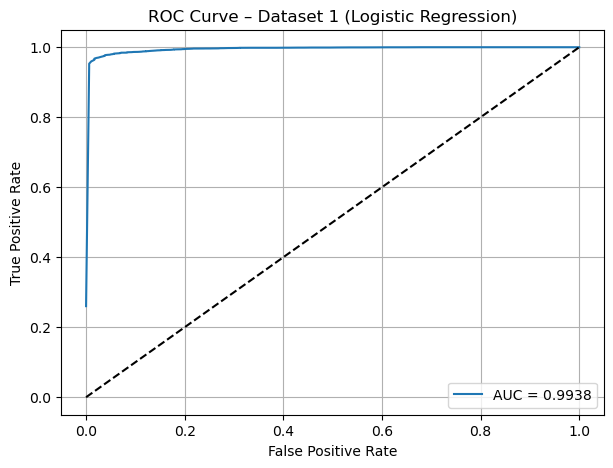

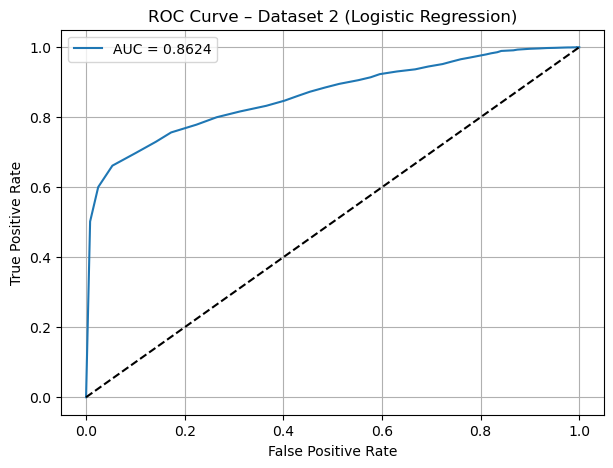

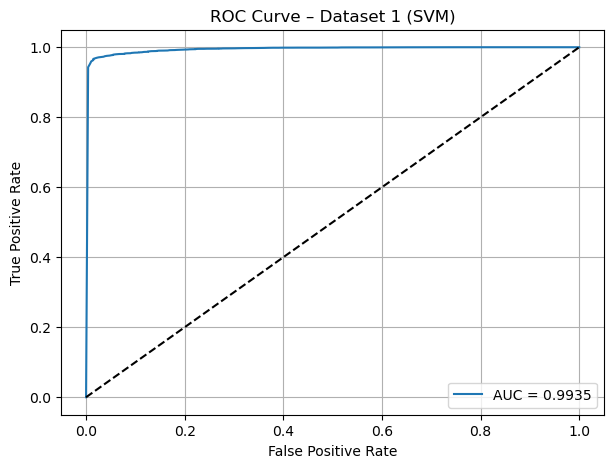

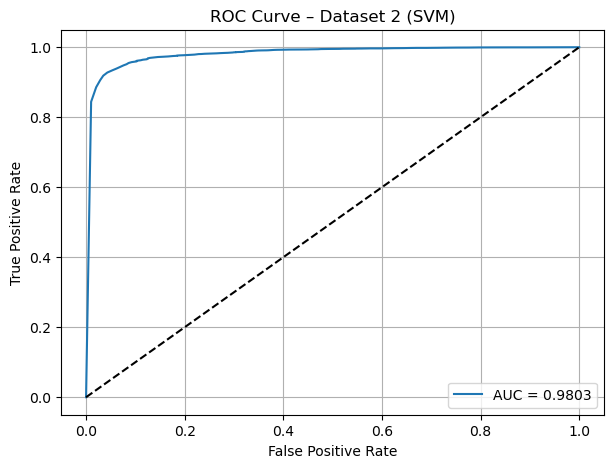

AUC

Logistic Regression :
Dataset 1 : 0.994
Dataset 2 : 0.862

SVM :
Dataset 1 : 0.993
Dataset 2 : 0.980


In [50]:
# Exercise 2.c)
import matplotlib.pyplot as plt
# To calculate the curves, it is fine to take 100 threshold values c, i.e.,
ths = np.linspace(0, 1, 100)

def compute_roc(y_true, y_score , ths) :

    TPR = []
    FPR = []

    for t in ths :
        y_pred = (y_score >= t).astype(int)

        tp = ((y_pred == 1) & (y_true == 1)).sum()
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        tn = ((y_pred == 0) & (y_true == 0)).sum()
        fn = ((y_pred == 0) & (y_true == 1)).sum()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        TPR.append(tpr)
        FPR.append(fpr)
    
    return np.array(FPR), np.array(TPR)

def compute_auc(fpr, tpr):
    order = np.argsort(fpr)
    fpr_sorted = fpr[order]
    tpr_sorted = tpr[order]

    auc = 0.0
    for i in range(len(fpr_sorted) - 1):
        auc += 0.5 * (tpr_sorted[i] + tpr_sorted[i+1]) * (fpr_sorted[i+1] - fpr_sorted[i])
    return auc


def plot_roc_curve(fpr, tpr, auc, title):
    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# To approximately calculate the AUC, it is fine to simply use Riemann sums.
# This means, if you have 100 (a_i, b_i) pairs for the curves, a_1 <= a_2 <= ...
# then you may simply use the sum
# sum_{i=1}^99 (b_i + b_{i+1})/2 * (a_{i+1}-a_i)
# as the approximation of the integral (or AUC)

# first data set & logistic regression:
# (the code should be reusable for all cases, only exchanging datasets and predicted probabilities depending on the model)
fpr_log_1, tpr_log_1 = compute_roc(Y_test_1, pred_test_1, ths)
auc_log_1 = compute_auc(fpr_log_1, tpr_log_1)

plot_roc_curve(fpr_log_1, tpr_log_1, auc_log_1, "ROC Curve – Dataset 1 (Logistic Regression)")

# second data set & logistic regression:
fpr_log_2, tpr_log_2 = compute_roc(Y_test_2, pred_test_2, ths)
auc_log_2 = compute_auc(fpr_log_2, tpr_log_2)

plot_roc_curve(fpr_log_2, tpr_log_2, auc_log_2,"ROC Curve – Dataset 2 (Logistic Regression)")

# first data set and SVM:
fpr_svm_1, tpr_svm_1 = compute_roc(Y_test_1, pred_test_svm_1, ths)
auc_svm_1 = compute_auc(fpr_svm_1, tpr_svm_1)

plot_roc_curve(fpr_svm_1, tpr_svm_1, auc_svm_1,"ROC Curve – Dataset 1 (SVM)")

# second data set and SVM:
fpr_svm_2, tpr_svm_2 = compute_roc(Y_test_2, pred_test_svm_2, ths)
auc_svm_2 = compute_auc(fpr_svm_2, tpr_svm_2)

plot_roc_curve(fpr_svm_2, tpr_svm_2, auc_svm_2,"ROC Curve – Dataset 2 (SVM)")

print('AUC')
print()

print('Logistic Regression :')
print(f'Dataset 1 : {auc_log_1:.3f}')
print(f'Dataset 2 : {auc_log_2:.3f}')
print()

print('SVM :')
print(f'Dataset 1 : {auc_svm_1:.3f}')
print(f'Dataset 2 : {auc_svm_2:.3f}')



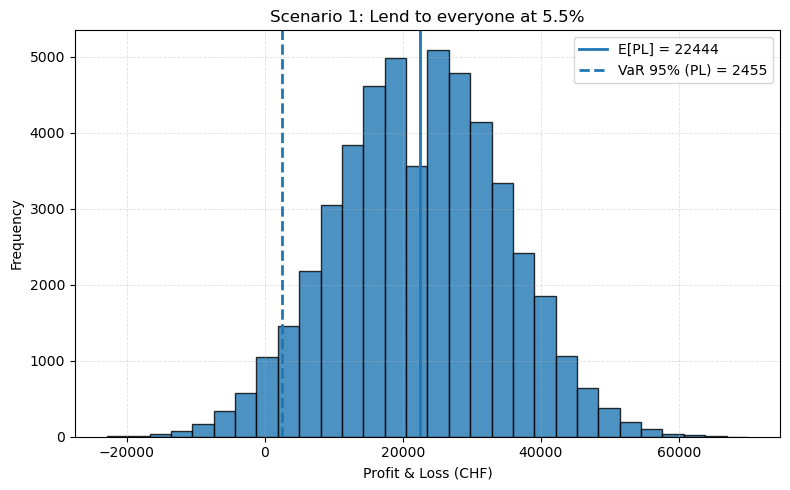

Scenario 1 results:
  Portfolio size: 10000
  Expected P&L:   22444.44 CHF
  95%-VaR:        2455.00 CHF
  95%-ES:         -2041.70 CHF



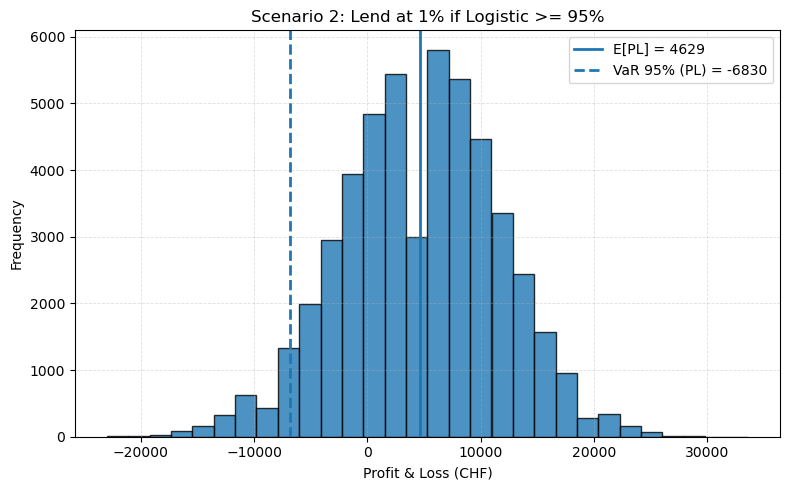

Scenario 2 results:
  Portfolio size: 6993
  Expected P&L:   4628.67 CHF
  95%-VaR:        -6830.00 CHF
  95%-ES:         -9468.61 CHF



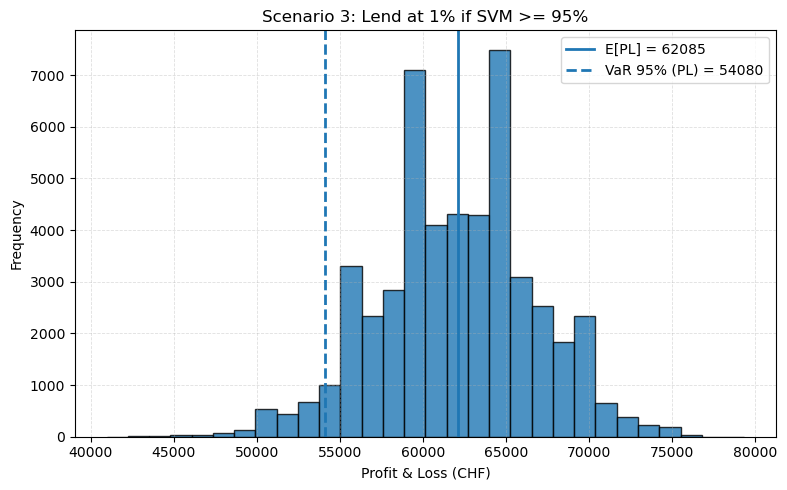

Scenario 3 results:
  Portfolio size: 8842
  Expected P&L:   62084.78 CHF
  95%-VaR:        54080.00 CHF
  95%-ES:         52298.01 CHF



In [53]:
# Exercise 3.

# Set model parameters and define matrix D

L = 1000.0          # loan amount (CHF)
r1 = 0.055          # interest rate scenario 1
r23 = 0.01          # interest rate scenarios 2 and 3
threshold = 0.95    # acceptance threshold
K = 50000           # number of scenarios
batch_size = 1000   # batching for RAM

# True repayment probabilities on the TEST set (dataset 2)
p2_test = p2[m:]  

# Predicted repayment probabilities on the TEST set (dataset 2)
pred_proba_log2 = pred_test_2          # logistic regression, already P(Y=1|X)
pred_proba_svm2 = pred_test_svm_2      # SVM, already P(Y=1|X)

n_test = len(p2_test)

# For rapidity of the code, We do NOT store the full matrix D of size (n_test \times K), we generate it in batches.
D = None


# Scenario 1:
# Define Portfolio and possible outcomes for this portfolio using matrix D

accept_1 = np.ones(n_test, dtype=bool)     # "lend to everyone"
p_acc_1 = p2_test[accept_1]
n_acc_1 = len(p_acc_1)

PL_1 = np.zeros(K)

start = 0
while start < K:
    end = min(start + batch_size, K)
    B = end - start

    U = np.random.rand(n_acc_1, B)
    D_batch = (U <= p_acc_1.reshape(-1, 1)).astype(int)   # simulated repayments
    R = np.sum(D_batch, axis=0)                           # number of repayments in each scenario

    PL_1[start:end] = L * ((1.0 + r1) * R - n_acc_1)
    start = end

# Calculate expected profit and losses, compute 95%-VaR and 95%-ES

exp_PL_1 = np.mean(PL_1)
VaR95_1 = np.quantile(PL_1, 0.05)           # quantile 5% of P&L <=> quantile 95% of loss
ES95_1  = np.mean(PL_1[PL_1 <= VaR95_1])    # conditionnal mean on this left tail

# Plot the histogram of profits and losses

plt.figure(figsize=(8,5))
plt.hist(PL_1, bins=30, edgecolor='black', alpha=0.8)
plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.4)
plt.axvline(exp_PL_1,   linewidth=2, linestyle='-',  label=f"E[PL] = {exp_PL_1:.0f}")
plt.axvline(VaR95_1, linewidth=2, linestyle='--', label=f"VaR 95% (PL) = {VaR95_1:.0f}")
plt.title("Scenario 1: Lend to everyone at 5.5%")
plt.xlabel("Profit & Loss (CHF)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

print("Scenario 1 results:")
print(f"  Portfolio size: {n_acc_1}")
print(f"  Expected P&L:   {exp_PL_1:.2f} CHF")
print(f"  95%-VaR:        {VaR95_1:.2f} CHF")
print(f"  95%-ES:         {ES95_1:.2f} CHF")
print()


# Scenario 2:
# Define Portfolio and possible outcomes using the matrix D and the predicted default probabilities from the logistic regression model

accept_2 = (pred_proba_log2 >= threshold)
p_acc_2 = p2_test[accept_2]     # simulation with TRUE probabilities (p2), not predicted ones
n_acc_2 = len(p_acc_2)

PL_2 = np.zeros(K)

start = 0
while start < K:
    end = min(start + batch_size, K)
    B = end - start

    U = np.random.rand(n_acc_2, B)
    D_batch = (U <= p_acc_2.reshape(-1, 1)).astype(int)
    R = np.sum(D_batch, axis=0)

    PL_2[start:end] = L * ((1.0 + r23) * R - n_acc_2)
    start = end


# Calculate expected profit and losses, compute 95%-VaR and 95%-ES

exp_PL_2 = np.mean(PL_2)
VaR95_2 = np.quantile(PL_2, 0.05)           # quantile 5% of P&L <=> quantile 95% of loss
ES95_2  = np.mean(PL_2[PL_2 <= VaR95_2])    # conditionnal mean on this left tail

# Plot the histogram of profits and losses

plt.figure(figsize=(8,5))
plt.hist(PL_2, bins=30, edgecolor='black', alpha=0.8)
plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.4)
plt.axvline(exp_PL_2,   linewidth=2, linestyle='-',  label=f"E[PL] = {exp_PL_2:.0f}")
plt.axvline(VaR95_2, linewidth=2, linestyle='--', label=f"VaR 95% (PL) = {VaR95_2:.0f}")
plt.title("Scenario 2: Lend at 1% if Logistic >= 95%")
plt.xlabel("Profit & Loss (CHF)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

print("Scenario 2 results:")
print(f"  Portfolio size: {n_acc_2}")
print(f"  Expected P&L:   {exp_PL_2:.2f} CHF")
print(f"  95%-VaR:        {VaR95_2:.2f} CHF")
print(f"  95%-ES:         {ES95_2:.2f} CHF")
print()


# Scenario 3:
# Define Portfolio and possible outcomes using the matrix D and the predicted default probabilities from the SVM model

accept_3 = (pred_proba_svm2 >= threshold)
p_acc_3 = p2_test[accept_3]     # again, simulation with TRUE probabilities (p2), not predicted ones
n_acc_3 = len(p_acc_3)

PL_3 = np.zeros(K)

start = 0
while start < K:
    end = min(start + batch_size, K)
    B = end - start

    U = np.random.rand(n_acc_3, B)
    D_batch = (U <= p_acc_3.reshape(-1, 1)).astype(int)
    R = np.sum(D_batch, axis=0)

    PL_3[start:end] = L * ((1.0 + r23) * R - n_acc_3)
    start = end


# Calculate expected profit and losses, compute 95%-VaR and 95%-ES

exp_PL_3 = np.mean(PL_3)
VaR95_3 = np.quantile(PL_3, 0.05)              # quantile 5% of P&L <=> quantile 95% of loss
ES95_3  = np.mean(PL_3[PL_3 <= VaR95_3])       # conditionnal mean on this left tail

# Plot the histogram of profits and losses

plt.figure(figsize=(8,5))
plt.hist(PL_3, bins=30, edgecolor='black', alpha=0.8)
plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.4)
plt.axvline(exp_PL_3,   linewidth=2, linestyle='-',  label=f"E[PL] = {exp_PL_3:.0f}")
plt.axvline(VaR95_3, linewidth=2, linestyle='--', label=f"VaR 95% (PL) = {VaR95_3:.0f}")
plt.title("Scenario 3: Lend at 1% if SVM >= 95%")
plt.xlabel("Profit & Loss (CHF)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


print("Scenario 3 results:")
print(f"  Portfolio size: {n_acc_3}")
print(f"  Expected P&L:   {exp_PL_3:.2f} CHF")
print(f"  95%-VaR:        {VaR95_3:.2f} CHF")
print(f"  95%-ES:         {ES95_3:.2f} CHF")
print()
